# Lab 3 – Decision Tree Classification: Training, Evaluation & Overfitting

**Name:** Abdul Wali
**Student ID:** 023-24-0174
**Section:** F
**GitHub Profile:** AWS9760
**Dataset:** Telco Customer Churn (clean_churn)
**Dataset Source:** Telco Customer Churn dataset (Kaggle)

## Part 1 — Problem Definition & Dataset Verification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('clean_churn.csv')
print(df.shape)
df.info()

(7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    


In [2]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Task 2 — Problem restatement**

I'm predicting whether a given customer will churn (`Churn` = Yes/No) based on their account, service, and billing
profile. This matters to the business because retaining an existing customer is far cheaper than acquiring a new
one — if the model can flag at-risk customers early, the company can target them with retention offers before they
actually leave. The dataset is intact: 7,043 rows, 20 columns, no missing values, and the target is still an
imbalanced Yes/No split (as found in Lab 2).

## Part 2 — Feature & Target Preparation

In [3]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [4]:
X = df.drop(columns=['Churn'])
X.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [5]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X.shape

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_254/1572753530.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


(7043, 30)

**Task 4 — Encoding justification**

I used one-hot encoding (`pd.get_dummies`, with `drop_first=True` to avoid redundant dummy columns) for every
remaining categorical column instead of manual integer mapping. None of these columns (e.g. `Contract`,
`InternetService`, `PaymentMethod`) have a natural order, so assigning them arbitrary integers (0, 1, 2...) would
trick a Decision Tree's split logic into treating them as if they were ranked or numerically distant from each
other. One-hot encoding keeps each category as its own independent binary feature, which is the safer choice for
a tree-based model on nominal data. There was no need to hand-map `Churn` to `Yes`/`No` here since that's the
target, already encoded above — `get_dummies` was applied only to the feature matrix `X`.

In [6]:
print(X.isnull().sum().sum(), "missing values")
print(X.dtypes.value_counts())

0 missing values
bool       27
float64     2
int64       1
Name: count, dtype: int64


## Part 3 — Train/Test Split

**Task 6 — Why `stratify=y`**

Lab 2 showed the target is imbalanced (about 73% "No" vs. 27% "Yes"). Without stratifying, a random split could by
chance land a training or test set with a noticeably different churn rate than the full dataset, which would skew
evaluation — especially with the already-small "Yes" class. `stratify=y` forces both the train and test sets to
keep roughly the same 73/27 split as the original data, so the test set is a fair, representative sample to
evaluate against.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


## Part 4 — Baseline Decision Tree

In [8]:
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

y_train_pred_base = baseline_model.predict(X_train)
y_test_pred_base = baseline_model.predict(X_test)

print("Tree depth grown:", baseline_model.get_depth())

Tree depth grown: 23


**Task 9 — Depth grown**

Left unrestricted, scikit-learn grew the baseline tree to a depth of **23**. That's not surprising once you think
about it: with 30 one-hot-encoded features and no depth limit, a Decision Tree will keep splitting until every leaf
is pure (or as close to it as the data allows), carving out increasingly specific, noisy rules to fit individual
training rows. It's a strong early signal that this baseline tree is going to overfit.

## Part 5 — Model Evaluation

In [9]:
metrics_baseline = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_test_pred_base)],
    'Precision': [precision_score(y_test, y_test_pred_base)],
    'Recall': [recall_score(y_test, y_test_pred_base)],
    'F1-score': [f1_score(y_test, y_test_pred_base)]
}, index=['Baseline Decision Tree'])

metrics_baseline.round(3)

,Accuracy,Precision,Recall,F1-score
Baseline Decision Tree,0.732,0.496,0.487,0.491


**Task 10 — Test-set metrics**

The baseline tree scores 73.2% accuracy, but precision (49.6%), recall (48.7%), and F1 (49.1%) all sit roughly
around the coin-flip mark for the churn class. That's a big drop-off from the headline accuracy number, and it's
the first concrete evidence that the unrestricted tree isn't generalizing well.

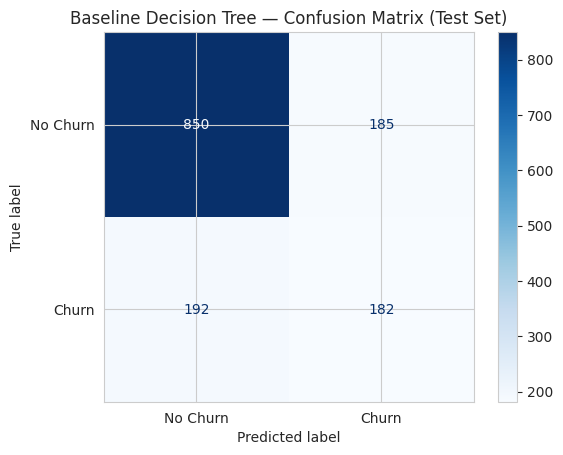

array([[850, 185],
       [192, 182]])

In [10]:
cm = confusion_matrix(y_test, y_test_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Baseline Decision Tree — Confusion Matrix (Test Set)')
plt.show()

cm

**Task 11 — Confusion matrix interpretation**

Of the 374 actual churners in the test set (192 + 182), the baseline model correctly caught **182** of them and
**missed 192** — it's wrong on the churn class more often than it's right, catching just under half. It also
raised 185 false alarms (predicted churn for customers who stayed). For a retention use case, missing over half
the actual churners is the more damaging failure mode, since those are the customers nobody follows up with.

**Task 12 — Which metric(s) to trust**

Given the class imbalance found in Lab 2 (~73% No / ~27% Yes), accuracy alone is not trustworthy — a model that
just predicted "No" for everyone would still score roughly 73% accuracy while catching zero churners, which is
useless for the business. Recall on the "Yes" (churn) class matters most here, since the whole point is to catch
customers who are about to leave; missing them (false negatives) is the costly mistake. Precision still matters
because chasing too many false alarms wastes retention budget, so F1-score — which balances the two — is the
single number I'd report if I had to pick just one.

## Part 6 — Overfitting Investigation

In [11]:
train_acc_base = accuracy_score(y_train, y_train_pred_base)
test_acc_base = accuracy_score(y_test, y_test_pred_base)

print(f"Baseline train accuracy: {train_acc_base:.3f}")
print(f"Baseline test accuracy:  {test_acc_base:.3f}")
print(f"Gap: {train_acc_base - test_acc_base:.3f}")

Baseline train accuracy: 0.998
Baseline test accuracy:  0.732
Gap: 0.266


**Task 13 — Train vs. test gap**

Yes, there's a large gap: the baseline tree scores **99.8%** accuracy on the training set but only **73.2%** on the
test set — a **26.6-point** drop. A model that near-perfectly memorizes the training data but performs far worse
on unseen data is the textbook signature of overfitting: it has learned noise and idiosyncrasies specific to the
training rows rather than generalizable churn patterns.

In [12]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test, model.predict(X_test))
    results.append({'max_depth': 'None (unrestricted)' if d is None else d,
                     'train_accuracy': tr_acc, 'test_accuracy': te_acc})

results_df = pd.DataFrame(results)
results_df.round(3)

,max_depth,train_accuracy,test_accuracy
0,2,0.791,0.787
1,3,0.791,0.787
2,4,0.793,0.796
3,5,0.802,0.794
4,6,0.811,0.801
5,8,0.836,0.782
6,10,0.873,0.757
7,None (unrestricted),0.998,0.732


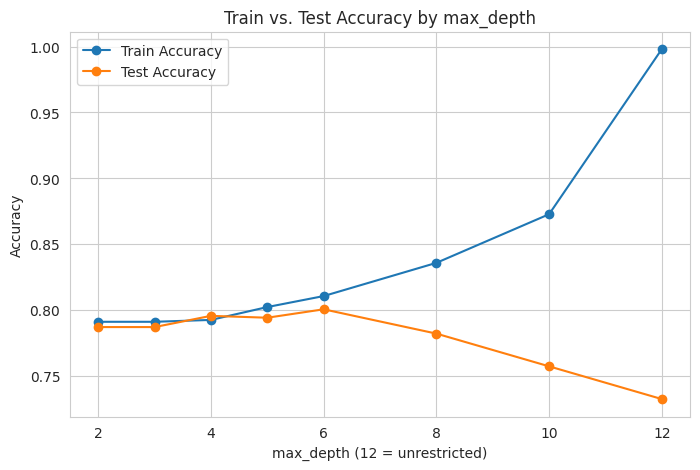

In [13]:
plot_depths = [2, 3, 4, 5, 6, 8, 10, 12]  # 12 stands in for "unrestricted" on the x-axis
plt.figure(figsize=(8, 5))
plt.plot(plot_depths, results_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(plot_depths, results_df['test_accuracy'], marker='o', label='Test Accuracy')
plt.xlabel('max_depth (12 = unrestricted)')
plt.ylabel('Accuracy')
plt.title('Train vs. Test Accuracy by max_depth')
plt.legend()
plt.grid(True)
plt.show()

**Task 15 — Where overfitting starts**

Test accuracy peaks around **max_depth = 6** (80.1%), staying close to train accuracy (81.1%, a gap of only about
1 point). Past that, the two curves start to pull apart: at depth 8 the gap widens to about 5 points, at depth 10
to about 12 points, and by the unrestricted tree it's nearly 27 points. On the chart, this shows up as the train
line climbing steadily toward ~100% while the test line rises only briefly, flattens, and then bends downward —
the classic overfitting shape. So depth 6–8 is roughly where the model stops learning generalizable patterns and
starts memorizing training-specific noise instead.

## Part 7 — Model Selection, Feature Importance & Interpretation

**Task 16 — Chosen depth & justification**

I'm choosing **max_depth = 6**. It has the highest test accuracy of any depth I tried (80.1%), and unlike depth 8
or 10 — which post higher *training* accuracy but a growing train/test gap — depth 6's train and test accuracy are
almost identical (81.1% vs. 80.1%, about a 1-point gap). That's exactly the balance the task asks for: not the
depth that memorizes training data best, but the one that generalizes best to data it hasn't seen.

In [14]:
CHOSEN_DEPTH = 6  # picked from results_df: best test accuracy with only a small train/test gap

chosen_model = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, random_state=42)
chosen_model.fit(X_train, y_train)
y_test_pred_chosen = chosen_model.predict(X_test)

metrics_chosen = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_test_pred_chosen)],
    'Precision': [precision_score(y_test, y_test_pred_chosen)],
    'Recall': [recall_score(y_test, y_test_pred_chosen)],
    'F1-score': [f1_score(y_test, y_test_pred_chosen)]
}, index=[f'Chosen Model (max_depth={CHOSEN_DEPTH})'])

comparison = pd.concat([metrics_baseline, metrics_chosen])
comparison.round(3)

,Accuracy,Precision,Recall,F1-score
Baseline Decision Tree,0.732,0.496,0.487,0.491
Chosen Model (max_depth=6),0.801,0.667,0.497,0.570


**Task 17 — Chosen model vs. baseline**

The depth-6 model trades a small amount of recall for a large jump in precision and overall reliability: accuracy
rises from 73.2% to **80.1%**, and precision jumps from 49.6% to **66.7%** — far fewer false alarms than the
baseline. Recall dips slightly (48.7% → 49.7%, essentially flat) and F1 improves from 0.491 to **0.570**. In short,
restricting depth didn't just make the model smaller — it made it noticeably more trustworthy on data it hasn't
seen, which is exactly the overfitting fix we were after.

In [15]:
entropy_model = DecisionTreeClassifier(max_depth=CHOSEN_DEPTH, criterion='entropy', random_state=42)
entropy_model.fit(X_train, y_train)
y_test_pred_entropy = entropy_model.predict(X_test)

metrics_entropy = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, y_test_pred_entropy)],
    'Precision': [precision_score(y_test, y_test_pred_entropy)],
    'Recall': [recall_score(y_test, y_test_pred_entropy)],
    'F1-score': [f1_score(y_test, y_test_pred_entropy)]
}, index=[f'Entropy Model (max_depth={CHOSEN_DEPTH})'])

comparison_full = pd.concat([metrics_baseline, metrics_chosen, metrics_entropy])
comparison_full.round(3)

,Accuracy,Precision,Recall,F1-score
Baseline Decision Tree,0.732,0.496,0.487,0.491
Chosen Model (max_depth=6),0.801,0.667,0.497,0.570
Entropy Model (max_depth=6),0.794,0.619,0.583,0.601


**Task 18 — Gini vs. entropy**

Switching the splitting criterion to entropy at the same depth (6) gives a very similar accuracy (79.4% vs. 80.1%
for gini) but a meaningfully different precision/recall trade-off: precision drops a bit (66.7% → 61.9%) while
recall rises noticeably (49.7% → 58.3%), pushing F1 up from 0.570 to **0.601**. For this business problem, where
catching churners matters more than avoiding false alarms, the entropy criterion's better recall makes it arguably
the stronger choice at this depth — the two splitting rules aren't interchangeable in practice, even though their
overall accuracy looks close.

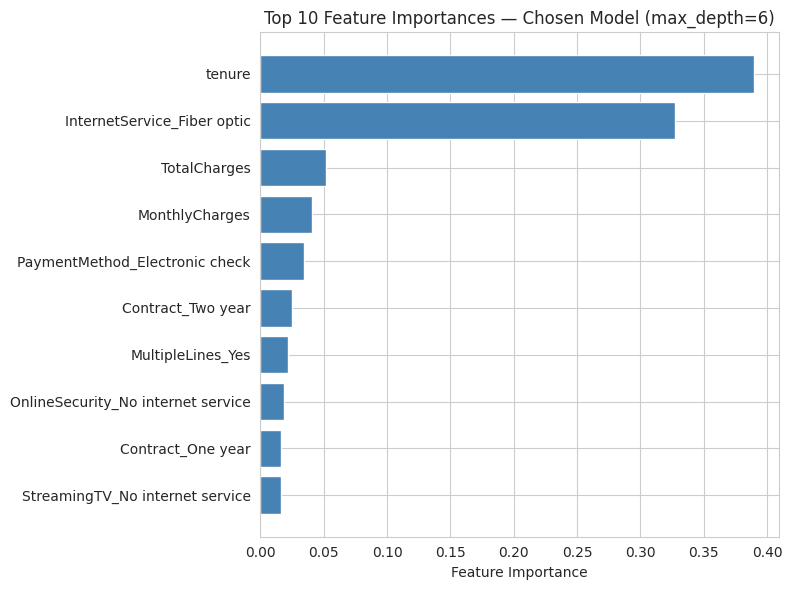

tenure                                0.389640
InternetService_Fiber optic           0.327372
TotalCharges                          0.051916
MonthlyCharges                        0.040819
PaymentMethod_Electronic check        0.034488
Contract_Two year                     0.024794
MultipleLines_Yes                     0.021636
OnlineSecurity_No internet service    0.018925
Contract_One year                     0.016172
StreamingTV_No internet service       0.015912
dtype: float64

In [16]:
importances = pd.Series(chosen_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title(f'Top 10 Feature Importances — Chosen Model (max_depth={CHOSEN_DEPTH})')
plt.tight_layout()
plt.show()

top_features

**Task 19 — Top features**

The five most important features are **`tenure`** (0.39), **`InternetService_Fiber optic`** (0.33),
**`TotalCharges`** (0.05), **`MonthlyCharges`** (0.04), and **`PaymentMethod_Electronic check`** (0.03). Together
`tenure` and fiber-optic internet account for roughly 72% of the model's total decision-making weight — by far the
two dominant drivers of predicted churn, with billing-related features a distant second tier.

**Task 20 — Connection to Lab 2 EDA**

This lines up well with Lab 2's findings. `tenure` topping the importance list matches the EDA finding that
churners had a much lower median tenure than stayers (10 months vs. 38), and `InternetService_Fiber optic` being
the second most important feature echoes the earlier finding that month-to-month + fiber-optic customers had the
worst churn rate of any segment (54.6%). Billing-related features (`PaymentMethod_Electronic check`,
`MonthlyCharges`, `TotalCharges`) also show up in the top ranks, consistent with Lab 2's observation that
`TotalCharges` and `tenure` are closely related. The model essentially rediscovered the same risk factors the EDA
flagged by hand.

## Part 8 — Conclusion & Next Steps

**Task 21 — Conclusion**

I landed on a Decision Tree capped at **max_depth = 6**, chosen because it had the best test accuracy (80.1%) of
any depth tried while keeping training and test performance nearly identical, unlike the unrestricted baseline
which scored 99.8% on training but collapsed to 73.2% on the test set. The final model reaches 80.1% accuracy,
66.7% precision, and 49.7% recall on the churn class (F1 = 0.570); switching to an entropy-based split at the same
depth trades a bit of precision for better recall (F1 = 0.601), which may actually be the better pick for a
retention use case. `tenure` and `InternetService_Fiber optic` dominate the model's decisions, consistent with
Lab 2's EDA. The main limitation is recall — the model still misses roughly half of actual churners, which matters
a lot for a business trying to intervene before customers leave — and the underlying class imbalance in the
dataset is the most likely reason why.

**Task 22 — Next steps**

If I had more time I'd address the class imbalance directly — either with `class_weight='balanced'` in the
Decision Tree, or by resampling (SMOTE for the minority "Yes" class, or undersampling "No") — since right now the
model still leans toward predicting the majority class more than the business would like. I'd also try a
gradient-boosted tree (e.g. XGBoost or LightGBM), which usually captures non-linear interactions between features
like `Contract` and `InternetService` better than a single Decision Tree, and I'd look at engineering a couple of
interaction features (e.g. tenure buckets, or a combined "contract × internet type" flag) directly rather than
relying on the tree to rediscover that interaction on its own.

## Bonus — Task 23: ID3 from Scratch on the Play Badminton Dataset

No `scikit-learn` here — this builds entropy, information gain, and a recursive ID3 tree by hand on the small
classic "Play Badminton" dataset from class.

In [17]:
badminton_data = [
    {'Outlook': 'Sunny',    'Temperature': 'Hot',  'Humidity': 'High',   'Wind': 'Weak',   'PlayBadminton': 'No'},
    {'Outlook': 'Sunny',    'Temperature': 'Hot',  'Humidity': 'High',   'Wind': 'Strong', 'PlayBadminton': 'No'},
    {'Outlook': 'Overcast', 'Temperature': 'Hot',  'Humidity': 'High',   'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Rain',     'Temperature': 'Mild', 'Humidity': 'High',   'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Rain',     'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Rain',     'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayBadminton': 'No'},
    {'Outlook': 'Overcast', 'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayBadminton': 'Yes'},
    {'Outlook': 'Sunny',    'Temperature': 'Mild', 'Humidity': 'High',   'Wind': 'Weak',   'PlayBadminton': 'No'},
    {'Outlook': 'Sunny',    'Temperature': 'Cool', 'Humidity': 'Normal', 'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Rain',     'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Sunny',    'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Strong', 'PlayBadminton': 'Yes'},
    {'Outlook': 'Overcast', 'Temperature': 'Mild', 'Humidity': 'High',   'Wind': 'Strong', 'PlayBadminton': 'Yes'},
    {'Outlook': 'Overcast', 'Temperature': 'Hot',  'Humidity': 'Normal', 'Wind': 'Weak',   'PlayBadminton': 'Yes'},
    {'Outlook': 'Rain',     'Temperature': 'Mild', 'Humidity': 'High',   'Wind': 'Strong', 'PlayBadminton': 'No'},
]

badminton_df = pd.DataFrame(badminton_data)
badminton_df

,Outlook,Temperature,Humidity,Wind,PlayBadminton
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [18]:
import math

TARGET = 'PlayBadminton'

def entropy(rows):
    """Entropy of the target column over a list of dict rows."""
    n = len(rows)
    if n == 0:
        return 0.0
    counts = {}
    for r in rows:
        counts[r[TARGET]] = counts.get(r[TARGET], 0) + 1
    ent = 0.0
    for c in counts.values():
        p = c / n
        ent -= p * math.log2(p)
    return ent

def information_gain(rows, attribute):
    """Information gain from splitting `rows` on `attribute`."""
    total_entropy = entropy(rows)
    n = len(rows)
    values = set(r[attribute] for r in rows)
    weighted_entropy = 0.0
    for v in values:
        subset = [r for r in rows if r[attribute] == v]
        weighted_entropy += (len(subset) / n) * entropy(subset)
    return total_entropy - weighted_entropy

def majority_class(rows):
    counts = {}
    for r in rows:
        counts[r[TARGET]] = counts.get(r[TARGET], 0) + 1
    return max(counts, key=counts.get)

def id3(rows, attributes, depth=0):
    labels = set(r[TARGET] for r in rows)

    # Pure node
    if len(labels) == 1:
        return labels.pop()

    # No attributes left to split on
    if not attributes:
        return majority_class(rows)

    # Compute and print gain for every candidate attribute at this split
    gains = {attr: information_gain(rows, attr) for attr in attributes}
    print(f"{'  ' * depth}Node at depth {depth} (n={len(rows)}), entropy={entropy(rows):.3f}")
    for attr, gain in sorted(gains.items(), key=lambda x: -x[1]):
        print(f"{'  ' * depth}  Gain({attr}) = {gain:.4f}")

    best_attr = max(gains, key=gains.get)
    print(f"{'  ' * depth}  --> Splitting on '{best_attr}'\n")

    tree = {best_attr: {}}
    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in set(r[best_attr] for r in rows):
        subset = [r for r in rows if r[best_attr] == value]
        if not subset:
            tree[best_attr][value] = majority_class(rows)
        else:
            tree[best_attr][value] = id3(subset, remaining_attrs, depth + 1)

    return tree

rows = badminton_df.to_dict('records')
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']

tree = id3(rows, attributes)
tree

Node at depth 0 (n=14), entropy=0.940
  Gain(Outlook) = 0.2467
  Gain(Humidity) = 0.1518
  Gain(Wind) = 0.0481
  Gain(Temperature) = 0.0292
  --> Splitting on 'Outlook'

  Node at depth 1 (n=5), entropy=0.971
    Gain(Humidity) = 0.9710
    Gain(Temperature) = 0.5710
    Gain(Wind) = 0.0200
    --> Splitting on 'Humidity'

  Node at depth 1 (n=5), entropy=0.971
    Gain(Wind) = 0.9710
    Gain(Temperature) = 0.0200
    Gain(Humidity) = 0.0200
    --> Splitting on 'Wind'



{'Outlook': {'Sunny': {'Humidity': {'Normal': 'Yes', 'High': 'No'}},
  'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}},
  'Overcast': 'Yes'}}

In [19]:
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree
    attr = next(iter(tree))
    value = sample.get(attr)
    branch = tree[attr].get(value)
    if branch is None:
        return None
    return predict(branch, sample)

# Sanity check: predict on the training rows themselves
correct = sum(predict(tree, r) == r[TARGET] for r in rows)
print(f"Training accuracy of the hand-built ID3 tree: {correct}/{len(rows)}")

Training accuracy of the hand-built ID3 tree: 14/14


**Task 23 — Notes on the hand-built ID3 tree**

The printed gain values above show `Outlook` wins the very first split — it has the highest information gain among
the four attributes, since splitting on it does the most to reduce entropy about whether badminton gets played. The
resulting tree perfectly classifies the training data (a pure tree over only 14 examples is expected here — this
mirrors the overfitting behavior explored earlier with `scikit-learn`'s unrestricted Decision Tree in Part 6, just
on a much smaller dataset).